In [50]:
import pandas as pd
import numpy as np
import seaborn as sns
from imblearn.over_sampling import SMOTE
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import StandardScaler,LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix, classification_report

In [51]:
data=pd.read_csv("C:\\Users\\cathr\\Downloads\\p1\\winequalityN.csv")
data

,type,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,white,7.0,0.270,0.36,20.7,0.045,45.0,170.0,1.00100,3.00,0.45,8.8,6
1,white,6.3,0.300,0.34,1.6,0.049,14.0,132.0,0.99400,3.30,0.49,9.5,6
2,white,8.1,0.280,0.40,6.9,0.050,30.0,97.0,0.99510,3.26,0.44,10.1,6
3,white,7.2,0.230,0.32,8.5,0.058,47.0,186.0,0.99560,3.19,0.40,9.9,6
4,white,7.2,0.230,0.32,8.5,0.058,47.0,186.0,0.99560,3.19,0.40,9.9,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6492,red,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5
6493,red,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,NaN,11.2,6
6494,red,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6
6495,red,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,5


In [52]:
data.shape

(6497, 13)

In [53]:
#dependent data='type'  ,'independent data'='ixed acidity','volatile acidity','citric acid','residual sugar','chlorides	','ree sulfur dioxide','total sulfur dioxide','density','pH','sulphate',',alcohol','quality'

In [54]:
data.head()

,type,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,white,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6
1,white,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6
2,white,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6
3,white,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6
4,white,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6


In [55]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   type                  6497 non-null   object 
 1   fixed acidity         6487 non-null   float64
 2   volatile acidity      6489 non-null   float64
 3   citric acid           6494 non-null   float64
 4   residual sugar        6495 non-null   float64
 5   chlorides             6495 non-null   float64
 6   free sulfur dioxide   6497 non-null   float64
 7   total sulfur dioxide  6497 non-null   float64
 8   density               6497 non-null   float64
 9   pH                    6488 non-null   float64
 10  sulphates             6493 non-null   float64
 11  alcohol               6497 non-null   float64
 12  quality               6497 non-null   int64  
dtypes: float64(11), int64(1), object(1)
memory usage: 660.0+ KB


In [56]:
data.isnull().sum()

type                     0
fixed acidity           10
volatile acidity         8
citric acid              3
residual sugar           2
chlorides                2
free sulfur dioxide      0
total sulfur dioxide     0
density                  0
pH                       9
sulphates                4
alcohol                  0
quality                  0
dtype: int64

In [57]:
#fixed acidity---volatile acidity---citric acid---residual sugar---chlorides--ph---sulphates

In [58]:
le=LabelEncoder()
data['type']=le.fit_transform(data['type'])
data

,type,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,1,7.0,0.270,0.36,20.7,0.045,45.0,170.0,1.00100,3.00,0.45,8.8,6
1,1,6.3,0.300,0.34,1.6,0.049,14.0,132.0,0.99400,3.30,0.49,9.5,6
2,1,8.1,0.280,0.40,6.9,0.050,30.0,97.0,0.99510,3.26,0.44,10.1,6
3,1,7.2,0.230,0.32,8.5,0.058,47.0,186.0,0.99560,3.19,0.40,9.9,6
4,1,7.2,0.230,0.32,8.5,0.058,47.0,186.0,0.99560,3.19,0.40,9.9,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6492,0,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5
6493,0,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,NaN,11.2,6
6494,0,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6
6495,0,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,5


In [59]:
data.corr()

,type,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
type,1.000000,-0.487241,-0.652875,0.187126,0.349000,-0.512622,0.471644,0.700357,-0.390645,-0.328727,-0.486916,0.032970,0.119323
fixed acidity,-0.487241,1.000000,0.220172,0.323736,-0.112319,0.298421,-0.283317,-0.329747,0.459204,-0.251814,0.300380,-0.095603,-0.077031
volatile acidity,-0.652875,0.220172,1.000000,-0.378061,-0.196702,0.377167,-0.353230,-0.414928,0.271193,0.260660,0.225476,-0.038248,-0.265953
citric acid,0.187126,0.323736,-0.378061,1.000000,0.142486,0.039315,0.133437,0.195218,0.096320,-0.328689,0.057613,-0.010433,0.085706
residual sugar,0.349000,-0.112319,-0.196702,0.142486,1.000000,-0.128902,0.403439,0.495820,0.552498,-0.267050,-0.185745,-0.359706,-0.036825
chlorides,-0.512622,0.298421,0.377167,0.039315,-0.128902,1.000000,-0.195042,-0.279580,0.362594,0.044806,0.395332,-0.256861,-0.200886
free sulfur dioxide,0.471644,-0.283317,-0.353230,0.133437,0.403439,-0.195042,1.000000,0.720934,0.025717,-0.145191,-0.188489,-0.179838,0.055463
total sulfur dioxide,0.700357,-0.329747,-0.414928,0.195218,0.495820,-0.279580,0.720934,1.000000,0.032395,-0.237687,-0.275381,-0.265740,-0.041385
density,-0.390645,0.459204,0.271193,0.096320,0.552498,0.362594,0.025717,0.032395,1.000000,0.011920,0.259454,-0.686745,-0.305858
pH,-0.328727,-0.251814,0.260660,-0.328689,-0.267050,0.044806,-0.145191,-0.237687,0.011920,1.000000,0.191248,0.121002,0.019366


In [60]:
#NULL VALUES---fixed acidity---volatile acidity---citric acid---residual sugar---chlorides--ph---sulphates

<Axes: xlabel='fixed acidity', ylabel='Count'>

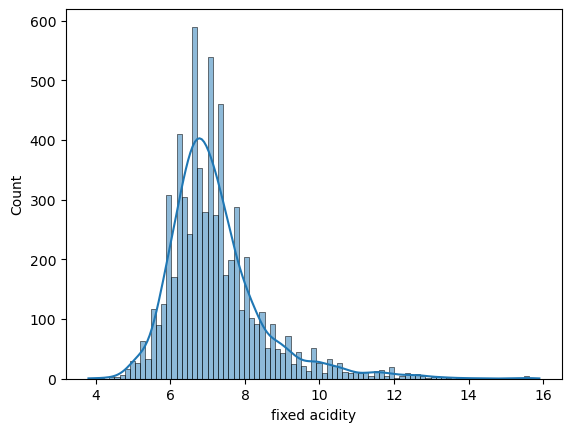

In [61]:
sns.histplot(x="fixed acidity",data=data,kde=True)

<Axes: xlabel='volatile acidity', ylabel='Count'>

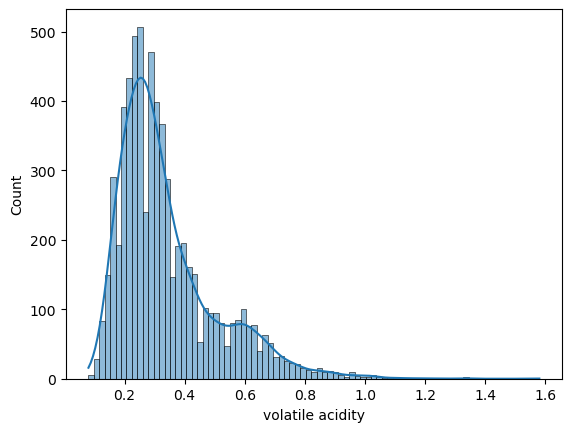

In [62]:
sns.histplot(x="volatile acidity",data=data,kde=True)

<Axes: xlabel='citric acid', ylabel='Count'>

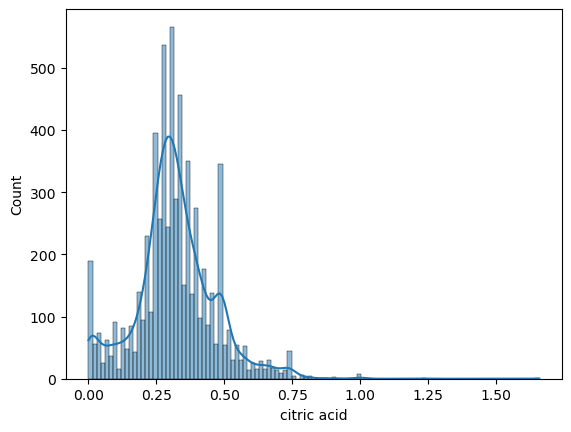

In [63]:
sns.histplot(x="citric acid",data=data,kde=True)

<Axes: xlabel='residual sugar', ylabel='Count'>

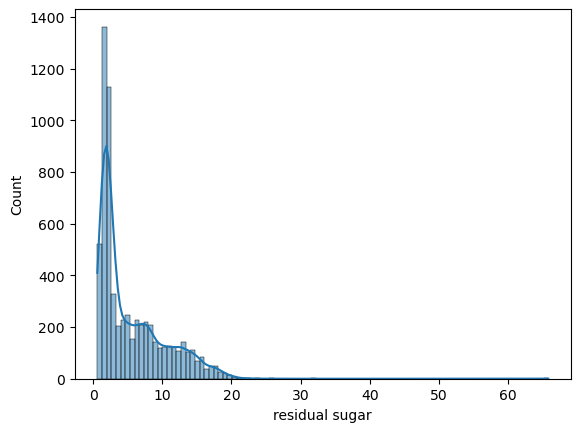

In [64]:
sns.histplot(x="residual sugar",data=data,kde=True)

<Axes: xlabel='chlorides', ylabel='Count'>

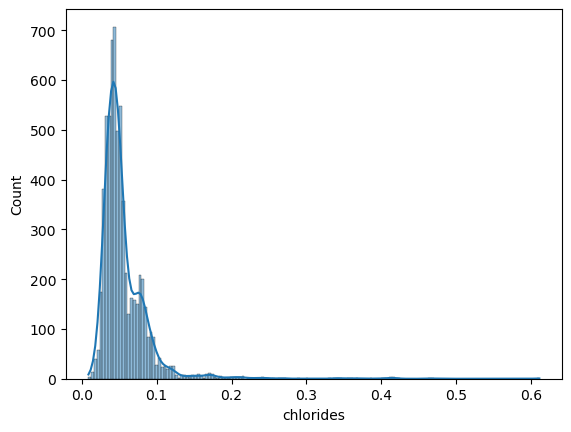

In [65]:
sns.histplot(x="chlorides",data=data,kde=True)

<Axes: xlabel='pH', ylabel='Count'>

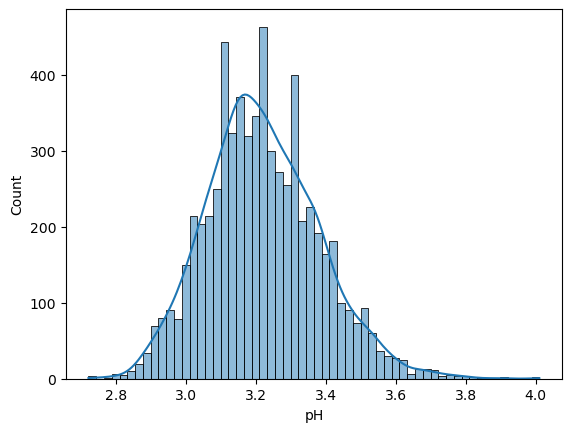

In [66]:
sns.histplot(x="pH",data=data,kde=True)

<Axes: xlabel='sulphates', ylabel='Count'>

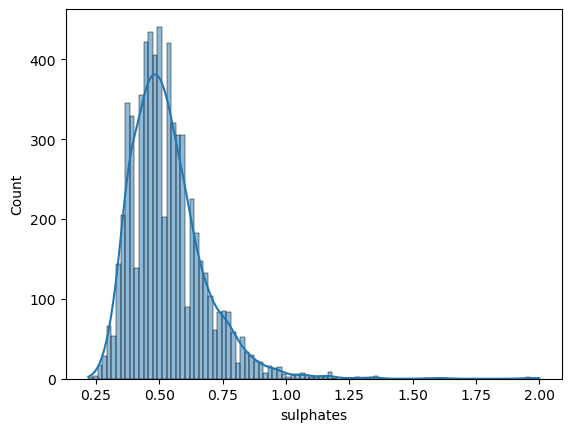

In [67]:
sns.histplot(x="sulphates",data=data,kde=True)

In [68]:
data['type'].unique()

array([1, 0])

In [69]:
data.groupby('type')['sulphates'].median()


type
0    0.62
1    0.47
Name: sulphates, dtype: float64

In [70]:
data['sulphates'].median()

0.51

In [71]:
data['sulphates']=data['sulphates'].fillna(data.groupby('type')['sulphates'].transform('median'))
data

,type,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,1,7.0,0.270,0.36,20.7,0.045,45.0,170.0,1.00100,3.00,0.45,8.8,6
1,1,6.3,0.300,0.34,1.6,0.049,14.0,132.0,0.99400,3.30,0.49,9.5,6
2,1,8.1,0.280,0.40,6.9,0.050,30.0,97.0,0.99510,3.26,0.44,10.1,6
3,1,7.2,0.230,0.32,8.5,0.058,47.0,186.0,0.99560,3.19,0.40,9.9,6
4,1,7.2,0.230,0.32,8.5,0.058,47.0,186.0,0.99560,3.19,0.40,9.9,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6492,0,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5
6493,0,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.62,11.2,6
6494,0,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6
6495,0,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,5


In [72]:
data['fixed acidity']=data['fixed acidity'].fillna(data.groupby('type')['fixed acidity'].transform('median'))
data

,type,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,1,7.0,0.270,0.36,20.7,0.045,45.0,170.0,1.00100,3.00,0.45,8.8,6
1,1,6.3,0.300,0.34,1.6,0.049,14.0,132.0,0.99400,3.30,0.49,9.5,6
2,1,8.1,0.280,0.40,6.9,0.050,30.0,97.0,0.99510,3.26,0.44,10.1,6
3,1,7.2,0.230,0.32,8.5,0.058,47.0,186.0,0.99560,3.19,0.40,9.9,6
4,1,7.2,0.230,0.32,8.5,0.058,47.0,186.0,0.99560,3.19,0.40,9.9,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6492,0,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5
6493,0,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.62,11.2,6
6494,0,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6
6495,0,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,5


In [73]:
data['volatile acidity']=data['volatile acidity'].fillna(data.groupby('type')['volatile acidity'].transform('median'))
data

,type,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,1,7.0,0.270,0.36,20.7,0.045,45.0,170.0,1.00100,3.00,0.45,8.8,6
1,1,6.3,0.300,0.34,1.6,0.049,14.0,132.0,0.99400,3.30,0.49,9.5,6
2,1,8.1,0.280,0.40,6.9,0.050,30.0,97.0,0.99510,3.26,0.44,10.1,6
3,1,7.2,0.230,0.32,8.5,0.058,47.0,186.0,0.99560,3.19,0.40,9.9,6
4,1,7.2,0.230,0.32,8.5,0.058,47.0,186.0,0.99560,3.19,0.40,9.9,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6492,0,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5
6493,0,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.62,11.2,6
6494,0,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6
6495,0,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,5


In [74]:
data['citric acid']=data['citric acid'].fillna(data.groupby('type')['citric acid'].transform('median'))
data

,type,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,1,7.0,0.270,0.36,20.7,0.045,45.0,170.0,1.00100,3.00,0.45,8.8,6
1,1,6.3,0.300,0.34,1.6,0.049,14.0,132.0,0.99400,3.30,0.49,9.5,6
2,1,8.1,0.280,0.40,6.9,0.050,30.0,97.0,0.99510,3.26,0.44,10.1,6
3,1,7.2,0.230,0.32,8.5,0.058,47.0,186.0,0.99560,3.19,0.40,9.9,6
4,1,7.2,0.230,0.32,8.5,0.058,47.0,186.0,0.99560,3.19,0.40,9.9,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6492,0,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5
6493,0,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.62,11.2,6
6494,0,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6
6495,0,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,5


In [75]:
data['residual sugar']=data['residual sugar'].fillna(data.groupby('type')['residual sugar'].transform('median'))
data

,type,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,1,7.0,0.270,0.36,20.7,0.045,45.0,170.0,1.00100,3.00,0.45,8.8,6
1,1,6.3,0.300,0.34,1.6,0.049,14.0,132.0,0.99400,3.30,0.49,9.5,6
2,1,8.1,0.280,0.40,6.9,0.050,30.0,97.0,0.99510,3.26,0.44,10.1,6
3,1,7.2,0.230,0.32,8.5,0.058,47.0,186.0,0.99560,3.19,0.40,9.9,6
4,1,7.2,0.230,0.32,8.5,0.058,47.0,186.0,0.99560,3.19,0.40,9.9,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6492,0,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5
6493,0,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.62,11.2,6
6494,0,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6
6495,0,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,5


In [76]:
data['chlorides']=data['chlorides'].fillna(data.groupby('type')['chlorides'].transform('median'))
data

,type,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,1,7.0,0.270,0.36,20.7,0.045,45.0,170.0,1.00100,3.00,0.45,8.8,6
1,1,6.3,0.300,0.34,1.6,0.049,14.0,132.0,0.99400,3.30,0.49,9.5,6
2,1,8.1,0.280,0.40,6.9,0.050,30.0,97.0,0.99510,3.26,0.44,10.1,6
3,1,7.2,0.230,0.32,8.5,0.058,47.0,186.0,0.99560,3.19,0.40,9.9,6
4,1,7.2,0.230,0.32,8.5,0.058,47.0,186.0,0.99560,3.19,0.40,9.9,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6492,0,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5
6493,0,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.62,11.2,6
6494,0,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6
6495,0,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,5


In [77]:
data['pH']=data['pH'].fillna(data.groupby('type')['pH'].transform('median'))
data

,type,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,1,7.0,0.270,0.36,20.7,0.045,45.0,170.0,1.00100,3.00,0.45,8.8,6
1,1,6.3,0.300,0.34,1.6,0.049,14.0,132.0,0.99400,3.30,0.49,9.5,6
2,1,8.1,0.280,0.40,6.9,0.050,30.0,97.0,0.99510,3.26,0.44,10.1,6
3,1,7.2,0.230,0.32,8.5,0.058,47.0,186.0,0.99560,3.19,0.40,9.9,6
4,1,7.2,0.230,0.32,8.5,0.058,47.0,186.0,0.99560,3.19,0.40,9.9,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6492,0,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5
6493,0,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.62,11.2,6
6494,0,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6
6495,0,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,5


In [78]:
data.isnull().sum()

type                    0
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

In [79]:
data.shape

(6497, 13)

In [80]:
data.corr()

,type,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
type,1.000000,-0.487372,-0.653056,0.187181,0.348973,-0.512651,0.471644,0.700357,-0.390645,-0.328942,-0.487017,0.032970,0.119323
fixed acidity,-0.487372,1.000000,0.220139,0.323191,-0.112427,0.298356,-0.283366,-0.329840,0.458973,-0.251656,0.300193,-0.095500,-0.076987
volatile acidity,-0.653056,0.220139,1.000000,-0.377840,-0.196522,0.377185,-0.352900,-0.414954,0.271087,0.260961,0.225708,-0.037528,-0.265853
citric acid,0.187181,0.323191,-0.377840,1.000000,0.142493,0.039179,0.133396,0.195216,0.096289,-0.328815,0.057268,-0.010481,0.085684
residual sugar,0.348973,-0.112427,-0.196522,0.142493,1.000000,-0.128966,0.403217,0.495690,0.552492,-0.266824,-0.185794,-0.359642,-0.036832
chlorides,-0.512651,0.298356,0.377185,0.039179,-0.128966,1.000000,-0.194970,-0.279570,0.362591,0.045056,0.395449,-0.256869,-0.200707
free sulfur dioxide,0.471644,-0.283366,-0.352900,0.133396,0.403217,-0.194970,1.000000,0.720934,0.025717,-0.145364,-0.188526,-0.179838,0.055463
total sulfur dioxide,0.700357,-0.329840,-0.414954,0.195216,0.495690,-0.279570,0.720934,1.000000,0.032395,-0.237862,-0.275583,-0.265740,-0.041385
density,-0.390645,0.458973,0.271087,0.096289,0.552492,0.362591,0.025717,0.032395,1.000000,0.011997,0.259494,-0.686745,-0.305858
pH,-0.328942,-0.251656,0.260961,-0.328815,-0.266824,0.045056,-0.145364,-0.237862,0.011997,1.000000,0.191501,0.121027,0.019237


In [81]:
corr=data.corr()
threashold=0.5
sel_features=corr['type'][abs(corr['type'])>=threashold]
print(sel_features)

type                    1.000000
volatile acidity       -0.653056
chlorides              -0.512651
total sulfur dioxide    0.700357
Name: type, dtype: float64


In [82]:
data.drop(columns=['fixed acidity','citric acid','residual sugar','free sulfur dioxide','density','pH','sulphates','alcohol','quality'],inplace=True)

In [83]:
data

,type,volatile acidity,chlorides,total sulfur dioxide
0,1,0.270,0.045,170.0
1,1,0.300,0.049,132.0
2,1,0.280,0.050,97.0
3,1,0.230,0.058,186.0
4,1,0.230,0.058,186.0
...,...,...,...,...
6492,0,0.600,0.090,44.0
6493,0,0.550,0.062,51.0
6494,0,0.510,0.076,40.0
6495,0,0.645,0.075,44.0


In [84]:
y=data['type']
y

0       1
1       1
2       1
3       1
4       1
       ..
6492    0
6493    0
6494    0
6495    0
6496    0
Name: type, Length: 6497, dtype: int64

In [85]:
x=data.drop(columns=['type'])

In [86]:
x

,volatile acidity,chlorides,total sulfur dioxide
0,0.270,0.045,170.0
1,0.300,0.049,132.0
2,0.280,0.050,97.0
3,0.230,0.058,186.0
4,0.230,0.058,186.0
...,...,...,...
6492,0.600,0.090,44.0
6493,0.550,0.062,51.0
6494,0.510,0.076,40.0
6495,0.645,0.075,44.0


In [87]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)


In [88]:
data['type'].value_counts()

type
1    4898
0    1599
Name: count, dtype: int64

In [89]:
smote = SMOTE(sampling_strategy='minority')
x_sm, y_sm = smote.fit_resample(x_train, y_train)
y_sm.value_counts()

type
1    3912
0    3912
Name: count, dtype: int64

In [90]:
#LOGISTIC REGRESION
scaler=StandardScaler()
x_train_sm=scaler.fit_transform(x_sm)
x_test_sm=scaler.transform(x_test)
model_sm=  LogisticRegression()
model_sm.fit(x_train_sm,y_sm)
y_cap=model_sm.predict(x_test_sm)

sm = classification_report(y_test, y_cap, target_names=["0", "1"])
print("\nClassification Report:")
print(sm)


Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.95      0.93       314
           1       0.98      0.97      0.98       986

    accuracy                           0.96      1300
   macro avg       0.94      0.96      0.95      1300
weighted avg       0.96      0.96      0.96      1300



In [91]:
#KNN
scaler=StandardScaler()
x_train_sm=scaler.fit_transform(x_sm)
x_test_sm=scaler.transform(x_test)
model_sm=  KNeighborsClassifier()
model_sm.fit(x_train_sm,y_sm)
y_cap=model_sm.predict(x_test_sm)

sm = classification_report(y_test, y_cap, target_names=["0", "1"])
print("\nClassification Report:")
print(sm)


Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.97      0.96       314
           1       0.99      0.98      0.99       986

    accuracy                           0.98      1300
   macro avg       0.97      0.98      0.97      1300
weighted avg       0.98      0.98      0.98      1300



In [92]:
#-----HYPERPARAMETER TUNING
from sklearn.model_selection import RandomizedSearchCV 
model_1 = KNeighborsClassifier()
parameter ={'n_neighbors':[3,5,7], 'metric':['manhattan','euclidean']}
random = RandomizedSearchCV(estimator=model_1,param_distributions=parameter,cv=5,scoring='accuracy')
random.fit(x_train, y_train)
print("Best parameters:", random.best_params_)
print("Best CV score:", random.best_score_)

C:\Users\cathr\anaconda\Lib\site-packages\sklearn\model_selection\_search.py:317: UserWarning: The total space of parameters 6 is smaller than n_iter=10. Running 6 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Best parameters: {'n_neighbors': 3, 'metric': 'manhattan'}
Best CV score: 0.950549159694973


In [93]:
#SVM
scaler=StandardScaler()
x_train_sm=scaler.fit_transform(x_sm)
x_test_sm=scaler.transform(x_test)
model_sm=  SVC()
model_sm.fit(x_train_sm,y_sm)
y_cap=model_sm.predict(x_test_sm)

sm = classification_report(y_test, y_cap, target_names=["0", "1"])
print("\nClassification Report:")
print(sm)


Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.98      0.97       314
           1       0.99      0.99      0.99       986

    accuracy                           0.98      1300
   macro avg       0.97      0.98      0.98      1300
weighted avg       0.98      0.98      0.98      1300



In [101]:
#-----HYPERPARAMETER TUNING
from sklearn.model_selection import RandomizedSearchCV 
model_1 = SVC()
parameter ={'C': [0.1, 1, 7, 0.4], 'kernel': ['linear', 'rbf']}
random = RandomizedSearchCV(estimator=model_1,param_distributions=parameter,cv=5,scoring='accuracy')
random.fit(x_train, y_train)
print("Best parameters:", random.best_params_)
print("Best CV score:", random.best_score_)

C:\Users\cathr\anaconda\Lib\site-packages\sklearn\model_selection\_search.py:317: UserWarning: The total space of parameters 8 is smaller than n_iter=10. Running 8 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Best parameters: {'kernel': 'linear', 'C': 7}
Best CV score: 0.9653646257496113


In [98]:
#decision tree------no need to do scaling
#scaler=StandardScaler()
#x_train_sm=scaler.fit_transform(x_sm)
#x_test_sm=scaler.transform(x_test)
model_sm=  DecisionTreeClassifier()
model_sm.fit(x_train_sm,y_sm)
y_cap=model_sm.predict(x_test_sm)

sm = classification_report(y_test, y_cap, target_names=["0", "1"])
print("\nClassification Report:")
print(sm)


Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.98      0.96       314
           1       0.99      0.98      0.99       986

    accuracy                           0.98      1300
   macro avg       0.97      0.98      0.98      1300
weighted avg       0.98      0.98      0.98      1300



In [99]:
#NAIVE BIAS


In [103]:
data1=pd.read_csv("C:\\Users\\cathr\\Downloads\\p1\\winequalityN.csv")
data1

,type,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,white,7.0,0.270,0.36,20.7,0.045,45.0,170.0,1.00100,3.00,0.45,8.8,6
1,white,6.3,0.300,0.34,1.6,0.049,14.0,132.0,0.99400,3.30,0.49,9.5,6
2,white,8.1,0.280,0.40,6.9,0.050,30.0,97.0,0.99510,3.26,0.44,10.1,6
3,white,7.2,0.230,0.32,8.5,0.058,47.0,186.0,0.99560,3.19,0.40,9.9,6
4,white,7.2,0.230,0.32,8.5,0.058,47.0,186.0,0.99560,3.19,0.40,9.9,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6492,red,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5
6493,red,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,NaN,11.2,6
6494,red,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6
6495,red,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,5


In [104]:
le=LabelEncoder()
data1['type']=le.fit_transform(data1['type'])
data1

,type,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,1,7.0,0.270,0.36,20.7,0.045,45.0,170.0,1.00100,3.00,0.45,8.8,6
1,1,6.3,0.300,0.34,1.6,0.049,14.0,132.0,0.99400,3.30,0.49,9.5,6
2,1,8.1,0.280,0.40,6.9,0.050,30.0,97.0,0.99510,3.26,0.44,10.1,6
3,1,7.2,0.230,0.32,8.5,0.058,47.0,186.0,0.99560,3.19,0.40,9.9,6
4,1,7.2,0.230,0.32,8.5,0.058,47.0,186.0,0.99560,3.19,0.40,9.9,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6492,0,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5
6493,0,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,NaN,11.2,6
6494,0,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6
6495,0,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,5


In [105]:
#----fill null value
data1['sulphates']=data1['sulphates'].fillna(data1.groupby('type')['sulphates'].transform('median'))
data1['fixed acidity']=data1['fixed acidity'].fillna(data1.groupby('type')['fixed acidity'].transform('median'))
data1['volatile acidity']=data1['volatile acidity'].fillna(data1.groupby('type')['volatile acidity'].transform('median'))
data1['citric acid']=data1['citric acid'].fillna(data1.groupby('type')['citric acid'].transform('median'))
data1['residual sugar']=data1['residual sugar'].fillna(data1.groupby('type')['residual sugar'].transform('median'))
data1['chlorides']=data1['chlorides'].fillna(data1.groupby('type')['chlorides'].transform('median'))
data1['pH']=data1['pH'].fillna(data1.groupby('type')['pH'].transform('median'))

In [106]:
data1.isnull().sum()

type                    0
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

In [107]:
y=data1['type']
y

0       1
1       1
2       1
3       1
4       1
       ..
6492    0
6493    0
6494    0
6495    0
6496    0
Name: type, Length: 6497, dtype: int64

In [108]:
x=data1.drop(columns=['type'])
x

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.0,0.270,0.36,20.7,0.045,45.0,170.0,1.00100,3.00,0.45,8.8,6
1,6.3,0.300,0.34,1.6,0.049,14.0,132.0,0.99400,3.30,0.49,9.5,6
2,8.1,0.280,0.40,6.9,0.050,30.0,97.0,0.99510,3.26,0.44,10.1,6
3,7.2,0.230,0.32,8.5,0.058,47.0,186.0,0.99560,3.19,0.40,9.9,6
4,7.2,0.230,0.32,8.5,0.058,47.0,186.0,0.99560,3.19,0.40,9.9,6
...,...,...,...,...,...,...,...,...,...,...,...,...
6492,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5
6493,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.62,11.2,6
6494,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6
6495,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,5


In [109]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [110]:
smote = SMOTE(sampling_strategy='minority')
x_sm, y_sm = smote.fit_resample(x_train, y_train)
y_sm.value_counts()


type
1    3912
0    3912
Name: count, dtype: int64

In [111]:
scaler=StandardScaler()
x_train_sm=scaler.fit_transform(x_sm)
x_test_sm=scaler.transform(x_test)
model_sm= GaussianNB()
model_sm.fit(x_train_sm,y_sm)
y_cap=model_sm.predict(x_test_sm)

sm = classification_report(y_test, y_cap, target_names=["0", "1"])
print("\nClassification Report:")
print(sm)


Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.96      0.94       314
           1       0.99      0.98      0.98       986

    accuracy                           0.97      1300
   macro avg       0.96      0.97      0.96      1300
weighted avg       0.97      0.97      0.97      1300



In [2]:
#---MY MODEL WORKS BEST ON KNN, SVM, DECIION TREE----ACUURACY--0.98 

In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
from imblearn.over_sampling import SMOTE

from sklearn.ensemble import RandomForestClassifier

from sklearn.preprocessing import StandardScaler,LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix, classification_report
data1=pd.read_csv("C:\\Users\\cathr\\Downloads\\p1\\winequalityN.csv")
data1

,type,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,white,7.0,0.270,0.36,20.7,0.045,45.0,170.0,1.00100,3.00,0.45,8.8,6
1,white,6.3,0.300,0.34,1.6,0.049,14.0,132.0,0.99400,3.30,0.49,9.5,6
2,white,8.1,0.280,0.40,6.9,0.050,30.0,97.0,0.99510,3.26,0.44,10.1,6
3,white,7.2,0.230,0.32,8.5,0.058,47.0,186.0,0.99560,3.19,0.40,9.9,6
4,white,7.2,0.230,0.32,8.5,0.058,47.0,186.0,0.99560,3.19,0.40,9.9,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6492,red,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5
6493,red,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,NaN,11.2,6
6494,red,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6
6495,red,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,5


In [5]:
le=LabelEncoder()
data1['type']=le.fit_transform(data1['type'])
data1

,type,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,1,7.0,0.270,0.36,20.7,0.045,45.0,170.0,1.00100,3.00,0.45,8.8,6
1,1,6.3,0.300,0.34,1.6,0.049,14.0,132.0,0.99400,3.30,0.49,9.5,6
2,1,8.1,0.280,0.40,6.9,0.050,30.0,97.0,0.99510,3.26,0.44,10.1,6
3,1,7.2,0.230,0.32,8.5,0.058,47.0,186.0,0.99560,3.19,0.40,9.9,6
4,1,7.2,0.230,0.32,8.5,0.058,47.0,186.0,0.99560,3.19,0.40,9.9,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6492,0,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5
6493,0,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,NaN,11.2,6
6494,0,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6
6495,0,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,5


In [6]:
#----fill null value
data1['sulphates']=data1['sulphates'].fillna(data1.groupby('type')['sulphates'].transform('median'))
data1['fixed acidity']=data1['fixed acidity'].fillna(data1.groupby('type')['fixed acidity'].transform('median'))
data1['volatile acidity']=data1['volatile acidity'].fillna(data1.groupby('type')['volatile acidity'].transform('median'))
data1['citric acid']=data1['citric acid'].fillna(data1.groupby('type')['citric acid'].transform('median'))
data1['residual sugar']=data1['residual sugar'].fillna(data1.groupby('type')['residual sugar'].transform('median'))
data1['chlorides']=data1['chlorides'].fillna(data1.groupby('type')['chlorides'].transform('median'))
data1['pH']=data1['pH'].fillna(data1.groupby('type')['pH'].transform('median'))

In [7]:
data1.isnull().sum()

type                    0
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

In [8]:
x=data1.drop(columns=['type'])
x

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.0,0.270,0.36,20.7,0.045,45.0,170.0,1.00100,3.00,0.45,8.8,6
1,6.3,0.300,0.34,1.6,0.049,14.0,132.0,0.99400,3.30,0.49,9.5,6
2,8.1,0.280,0.40,6.9,0.050,30.0,97.0,0.99510,3.26,0.44,10.1,6
3,7.2,0.230,0.32,8.5,0.058,47.0,186.0,0.99560,3.19,0.40,9.9,6
4,7.2,0.230,0.32,8.5,0.058,47.0,186.0,0.99560,3.19,0.40,9.9,6
...,...,...,...,...,...,...,...,...,...,...,...,...
6492,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5
6493,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.62,11.2,6
6494,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6
6495,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,5


In [9]:
y=data1['type']
y

0       1
1       1
2       1
3       1
4       1
       ..
6492    0
6493    0
6494    0
6495    0
6496    0
Name: type, Length: 6497, dtype: int64

In [10]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [12]:
rf_model = RandomForestClassifier(n_estimators=177, max_features=5, max_depth=3, random_state=42)
rf_model.fit(x_train, y_train)
accuracy = rf_model.score(x_test, y_test)
print("Model Accuracy:", accuracy)

Model Accuracy: 0.9861538461538462


In [15]:
smote = SMOTE(sampling_strategy='minority')
x_sm, y_sm = smote.fit_resample(x_train, y_train)
y_sm.value_counts()

type
1    3912
0    3912
Name: count, dtype: int64

In [17]:

model_sm= RandomForestClassifier()
model_sm.fit(x_train_sm,y_sm)
y_cap=model_sm.predict(x_test_sm)

sm = classification_report(y_test, y_cap, target_names=["0", "1"])
print("\nClassification Report:")
print(sm)


Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.99      1.00       314
           1       1.00      1.00      1.00       986

    accuracy                           1.00      1300
   macro avg       1.00      1.00      1.00      1300
weighted avg       1.00      1.00      1.00      1300



In [18]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint
param_dist = {'n_estimators': randint(50,500),
              'max_depth': randint(1,20)}
rf = RandomForestClassifier()
rand_search = RandomizedSearchCV(rf, param_distributions = param_dist,n_iter=5, cv=5,verbose=1, n_jobs=-1)
rand_search.fit(x_train, y_train)
print("Best Hyperparameters:")
print(rand_search.best_params_)

Fitting 5 folds for each of 5 candidates, totalling 25 fits
Best Hyperparameters:
{'max_depth': 12, 'n_estimators': 161}
